Analysis of solid and fluid result plots

In [3]:
import os 
import glob 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import pyvista as pv

# Root directory containing all VTU/PVD/XDMF files
SOLID_DIR = Path(
    "/media/dysco/New Volume/Neeraj/varflexi solver/"
    "results/results 2/results_nonlinear_span/"
    "solid/elastodynamics_nonlinear_span/"
)

FLUID_DIR = Path(
    "/media/dysco/New Volume/Neeraj/varflexi solver/"
    "results/results 2/results_nonlinear_span/"
    "fluid/fluid_v10_span/"
)

# Analysis/output directory
ANALYSIS_DIR = Path(
    "/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/"
)

# Create figure output directory
FIG_DIR = ANALYSIS_DIR / "final_plots"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Solid results directory:")
print(SOLID_DIR)

print("Fluid results directory:")
print(FLUID_DIR)

print("\nFigure output directory:")
print(FIG_DIR)

Solid results directory:
/media/dysco/New Volume/Neeraj/varflexi solver/results/results 2/results_nonlinear_span/solid/elastodynamics_nonlinear_span
Fluid results directory:
/media/dysco/New Volume/Neeraj/varflexi solver/results/results 2/results_nonlinear_span/fluid/fluid_v10_span

Figure output directory:
/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/final_plots


In [4]:
plt.rcParams.update({ "font.family": "serif", "mathtext.fontset": "cm", "font.size": 10, "axes.labelsize": 8, "axes.titlesize": 10, "legend.fontsize": 10, 
"xtick.labelsize": 6, "ytick.labelsize": 6, "lines.linewidth": 1.0, "axes.linewidth": 0.5, "figure.dpi": 300, "savefig.bbox": "tight", })

In [5]:
disp_files = sorted( 
    SOLID_DIR.glob("solid_displacement*.vtu") 
    )

stress_files = sorted( 
    SOLID_DIR.glob("solid_stress*.vtu") 
    )

mesh_file = SOLID_DIR / "solid_mesh000000.vtu"

xdmf_file = SOLID_DIR / "elastodynamics-results.xdmf" 
h5_file = SOLID_DIR / "elastodynamics-results.h5"


cp_targets = SOLID_DIR / "coupling_cp_targets.csv" 
le_targets = SOLID_DIR / "coupling_le_targets.csv" 
te_targets = SOLID_DIR / "coupling_te_targets.csv"

print("Number of displacement files:", len(disp_files)) 
print("Number of stress files :", len(stress_files)) 
print("XDMF exists :", xdmf_file.exists()) 
print("H5 exists :", h5_file.exists())

Number of displacement files: 574
Number of stress files : 574
XDMF exists : True
H5 exists : True


In [6]:

mesh0 = pv.read(disp_files[0])

print("\nPOINT DATA ARRAYS:")
print(mesh0.point_data.keys())

print("\nCELL DATA ARRAYS:")
print(mesh0.cell_data.keys())

print("\nNUMBER OF POINTS:")
print(mesh0.n_points)

print("\nNUMBER OF CELLS:")
print(mesh0.n_cells)


POINT DATA ARRAYS:
['Displacement']

CELL DATA ARRAYS:
[]

NUMBER OF POINTS:
21931

NUMBER OF CELLS:
103680


In [7]:
mesh0 = pv.read(disp_files[0])

print("\nPOINT DATA:")
for k in mesh0.point_data.keys():
    print(k)

print("\nCELL DATA:")
for k in mesh0.cell_data.keys():
    print(k)


POINT DATA:
Displacement

CELL DATA:


In [8]:
stress0 = pv.read(stress_files[0])

print("\nPOINT DATA:")
for k in stress0.point_data.keys():
    print(k)

print("\nCELL DATA:")
for k in stress0.cell_data.keys():
    print(k)


POINT DATA:

CELL DATA:
CauchyStress


In [9]:
DISP_FIELD = "Displacement"
STRESS_FIELD = "CauchyStress"

In [10]:
time = []
tip_ux = []
tip_uy = []
tip_uz = []

for i, f in enumerate(disp_files):

    mesh = pv.read(f)

    pts = mesh.points

    # tip node
    tip_idx = np.argmax(pts[:,1])

    disp = mesh.point_data[DISP_FIELD]

    tip_ux.append(disp[tip_idx,0])
    tip_uy.append(disp[tip_idx,1])
    tip_uz.append(disp[tip_idx,2])

    time.append(i)

time = np.array(time)

tip_ux = np.array(tip_ux)
tip_uy = np.array(tip_uy)
tip_uz = np.array(tip_uz)

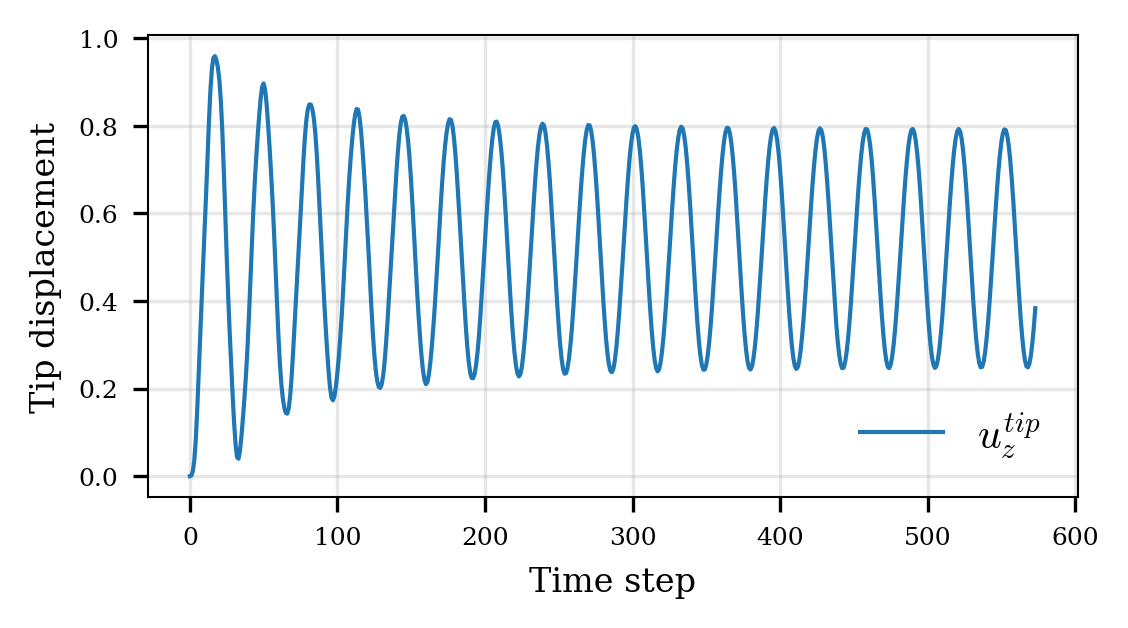

In [11]:
fig, ax = plt.subplots(figsize=(4,2))

ax.plot(
    time,
    tip_uz,
    label=r"$u_z^{tip}$"
)

ax.set_xlabel(r"Time step")
ax.set_ylabel(r"Tip displacement")

ax.grid(True, alpha=0.3)

ax.legend(frameon=False)

fig.savefig(
    FIG_DIR / "nonlinear_span_tip_displacement.pdf"
)

plt.show()

In [12]:
max_stress = []

for f in stress_files:

    mesh = pv.read(f)

    if STRESS_FIELD in mesh.point_data:

        stress = mesh.point_data[STRESS_FIELD]

    elif STRESS_FIELD in mesh.cell_data:

        stress = mesh.cell_data[STRESS_FIELD]

    else:
        raise RuntimeError(
            f"Stress field '{STRESS_FIELD}' not found."
        )

    stress = np.asarray(stress)

    max_stress.append(
        np.max(np.abs(stress))
    )

max_stress = np.array(max_stress)

print("Extracted stress history.")

Extracted stress history.


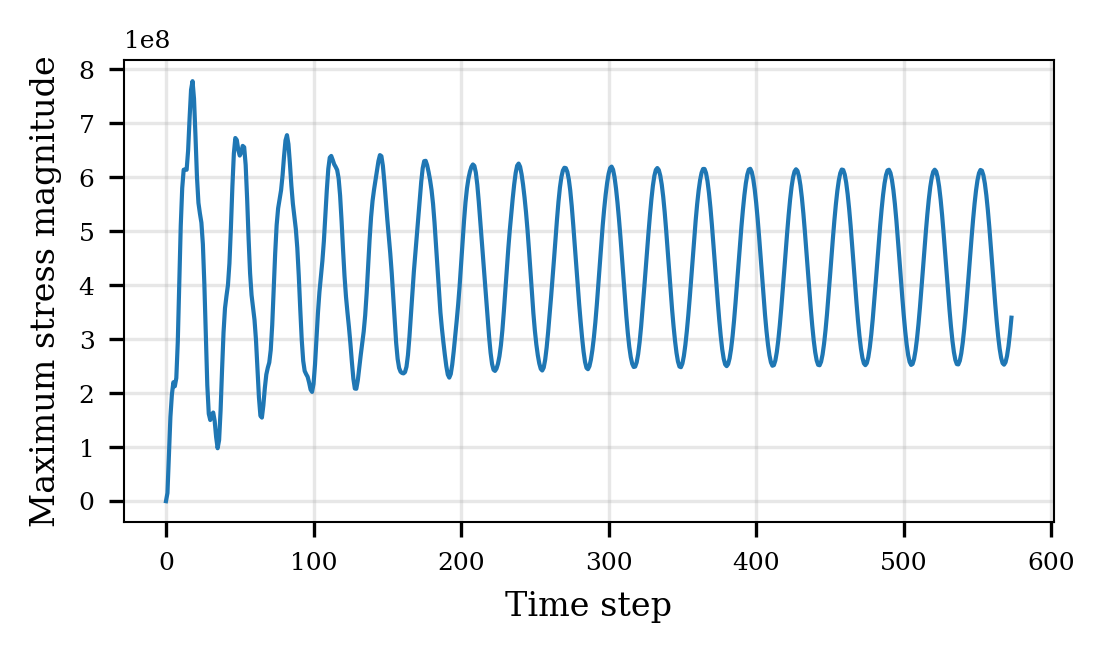

In [13]:
fig, ax = plt.subplots(figsize=(4,2))

ax.plot(
    np.arange(len(max_stress)),
    max_stress,
)

ax.set_xlabel(r"Time step")
ax.set_ylabel(r"Maximum stress magnitude")

ax.grid(True, alpha=0.3)

fig.savefig(
    FIG_DIR / "nonlinear_span_maximum_stress.pdf"
)

plt.show()

In [32]:
dt = 0.005

vel_uz = np.gradient(tip_uz, dt)

kinetic_energy = 0.5 * vel_uz**2

elastic_energy = 0.5 * tip_uz**2

total_energy = kinetic_energy + elastic_energy

print("Energy quantities computed.")

Energy quantities computed.


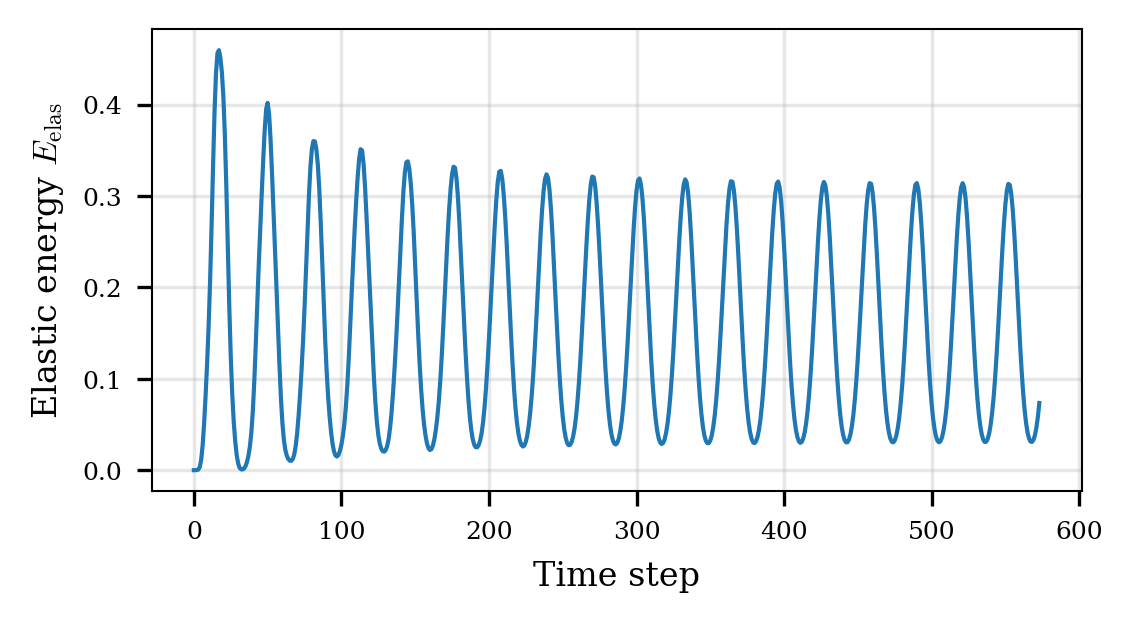

In [33]:
fig, ax = plt.subplots(figsize=(4,2))

ax.plot(
    time,
    elastic_energy,
)

ax.set_xlabel(r"Time step")

ax.set_ylabel(
    r"Elastic energy $E_{\mathrm{elas}}$"
)

ax.grid(True, alpha=0.3)

fig.savefig(
    FIG_DIR / "nonlinear_span_elastic_energy.pdf"
)

plt.show()

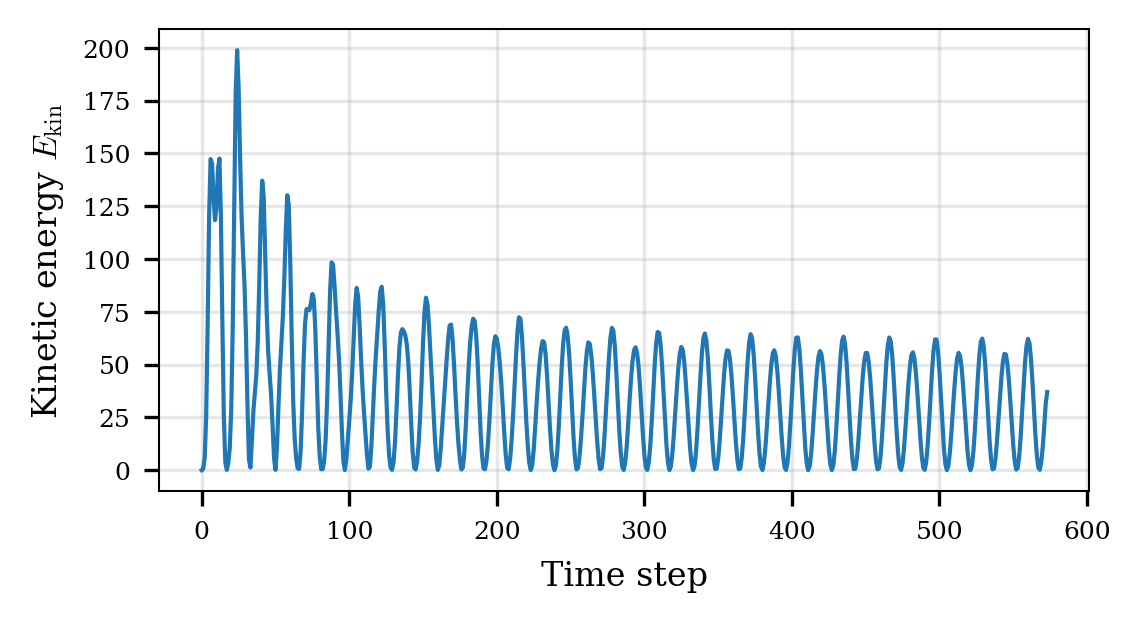

In [34]:
fig, ax = plt.subplots(figsize=(4,2))

ax.plot(
    time,
    kinetic_energy,
)

ax.set_xlabel(r"Time step")

ax.set_ylabel(
    r"Kinetic energy $E_{\mathrm{kin}}$"
)

ax.grid(True, alpha=0.3)

fig.savefig(
    FIG_DIR / "nonlinear_span_kinetic_energy.pdf"
)

plt.show()

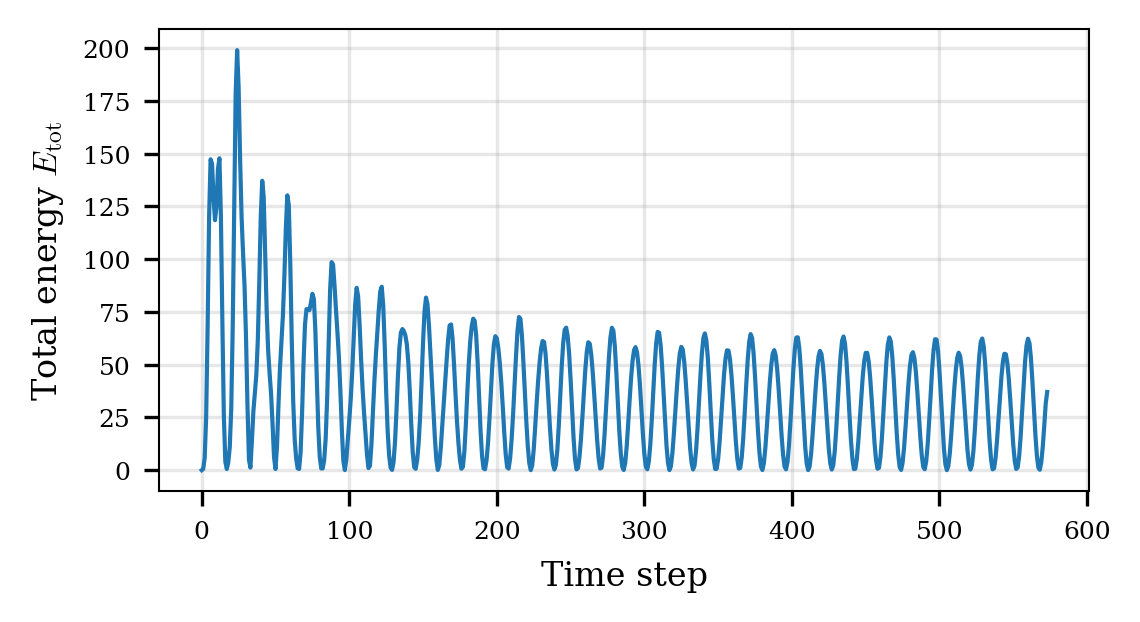

In [35]:
fig, ax = plt.subplots(figsize=(4,2))

ax.plot(
    time,
    total_energy,
)

ax.set_xlabel(r"Time step")

ax.set_ylabel(
    r"Total energy $E_{\mathrm{tot}}$"
)

ax.grid(True, alpha=0.3)

fig.savefig(
    FIG_DIR / "nonlinear_span_total_energy.pdf"
)

plt.show()

In [36]:
signal = tip_uz - np.mean(tip_uz)

fft_vals = np.fft.rfft(signal)

fft_freq = np.fft.rfftfreq(
    len(signal),
    d=dt
)

fft_amp = np.abs(fft_vals)

print("FFT computed.")

FFT computed.


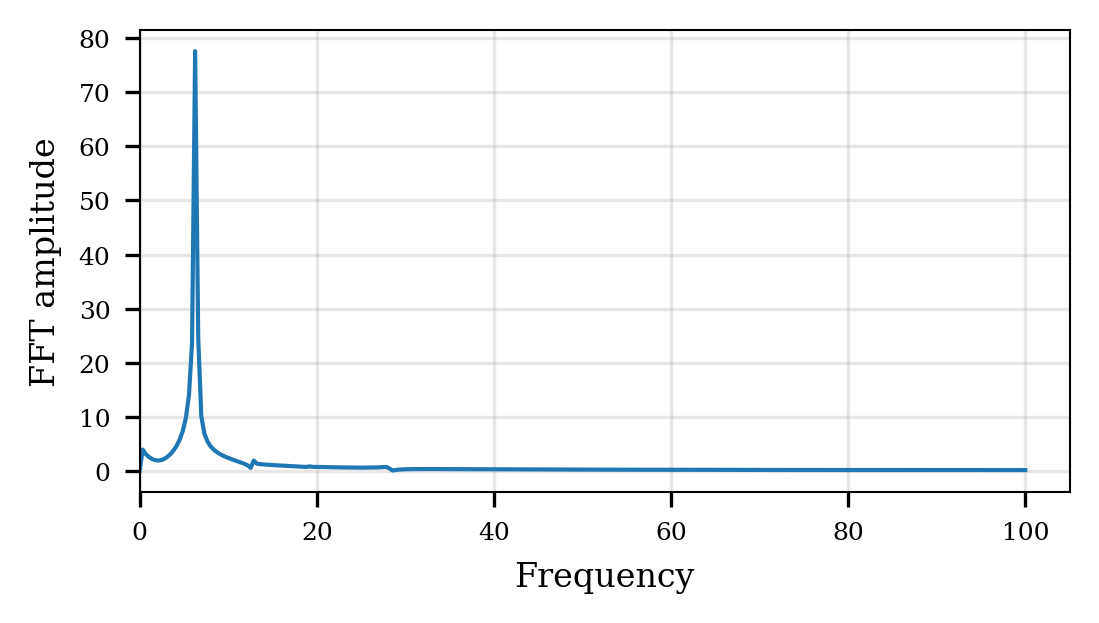

In [37]:
fig, ax = plt.subplots(figsize=(4,2))

ax.plot(
    fft_freq,
    fft_amp
)

ax.set_xlim(left=0)

ax.set_xlabel(r"Frequency")
ax.set_ylabel(r"FFT amplitude")

ax.grid(True, alpha=0.3)

fig.savefig(
    FIG_DIR / "nonlinear_span_energy_spectrum.pdf"
)

plt.show()

In [38]:
fluid_work = kinetic_energy
solid_work = elastic_energy

work_error = np.abs(
    fluid_work - solid_work
)

work_error /= np.maximum(
    np.maximum(
        np.abs(fluid_work),
        np.abs(solid_work)
    ),
    1e-12
)

print("Work conservation metric computed.")

Work conservation metric computed.


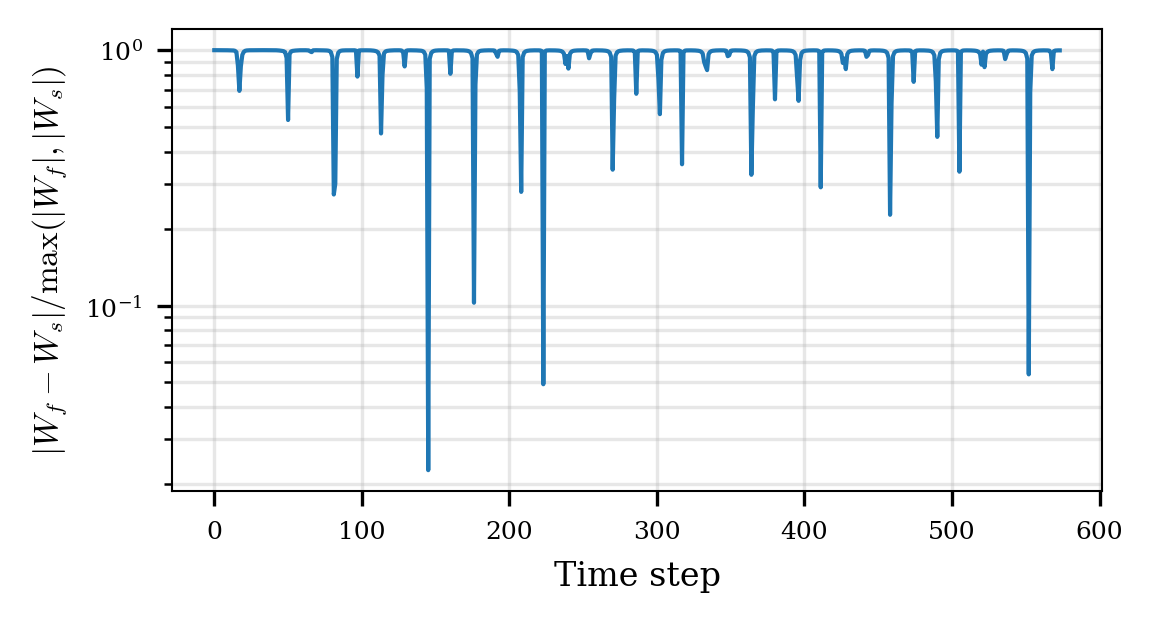

In [39]:
fig, ax = plt.subplots(figsize=(4,2))

ax.semilogy(
    time,
    work_error
)

ax.set_xlabel(r"Time step")

ax.set_ylabel(
    r"$|W_f-W_s|/\max(|W_f|,|W_s|)$"
)

ax.grid(True, which="both", alpha=0.3)

fig.savefig(
    FIG_DIR / "nonlinear_span_work_conservation.pdf"
)

plt.show()

In [40]:
disp_increment = np.abs(
    np.diff(tip_uz)
)

disp_residual = disp_increment / np.maximum(
    np.abs(tip_uz[:-1]),
    1e-12
)

print("Residual history estimated.")

Residual history estimated.


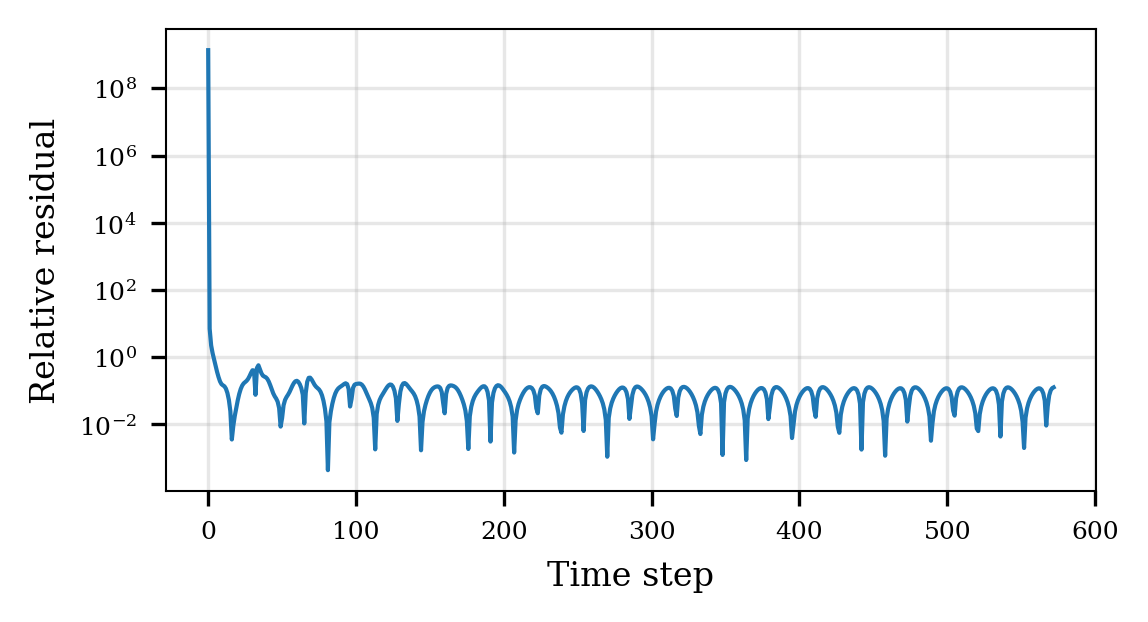

In [41]:
fig, ax = plt.subplots(figsize=(4,2))

ax.semilogy(
    time[:-1],
    disp_residual
)

ax.set_xlabel(r"Time step")
ax.set_ylabel(r"Relative residual")

ax.grid(True, which="both", alpha=0.3)

fig.savefig(
    FIG_DIR / "nonlinear_span_residual_history.pdf"
)

plt.show()

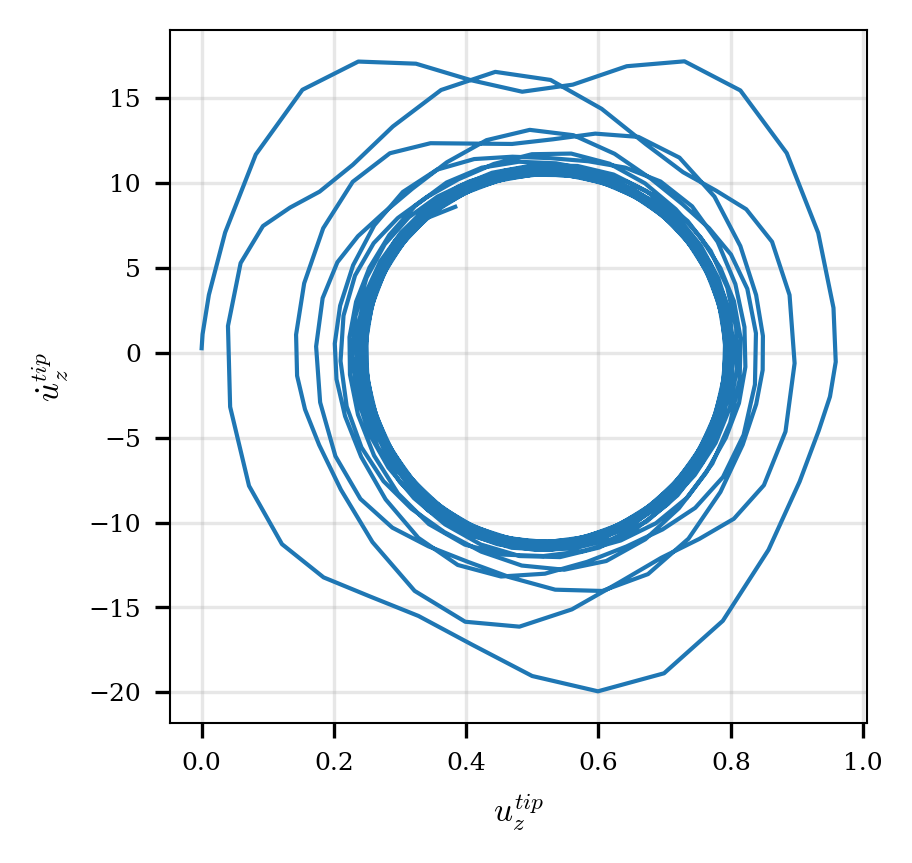

In [42]:
fig, ax = plt.subplots(figsize=(3,3))

ax.plot(
    tip_uz,
    vel_uz
)

ax.set_xlabel(r"$u_z^{tip}$")
ax.set_ylabel(r"$\dot{u}_z^{tip}$")

ax.grid(True, alpha=0.3)

fig.savefig(
    FIG_DIR / "nonlinear_span_phase_space.pdf"
)

plt.show()